Memproses Downsampling (Bisa memakan waktu beberapa detik)...
Memproses Upsampling Nearest Neighbor...
Memproses Upsampling Bilinear...
Memproses Upsampling Bicubic (Ini yang paling lambat)...

Menyimpan file hasil pemrosesan...
Memicu proses download file ke perangkatmu...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Menampilkan visualisasi plot...


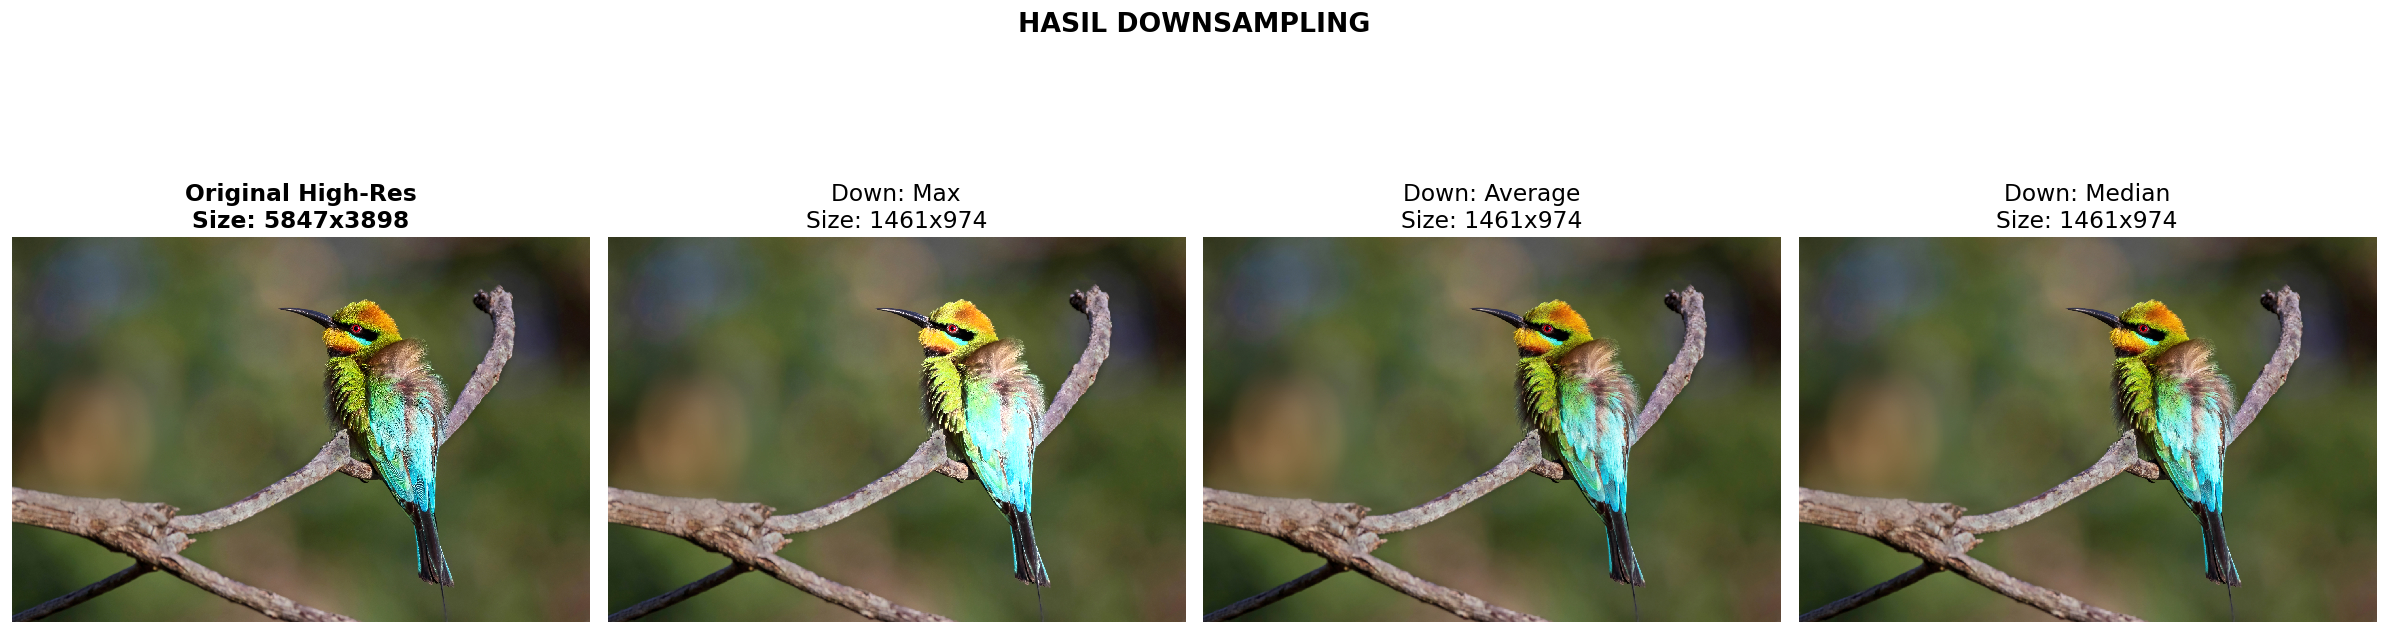

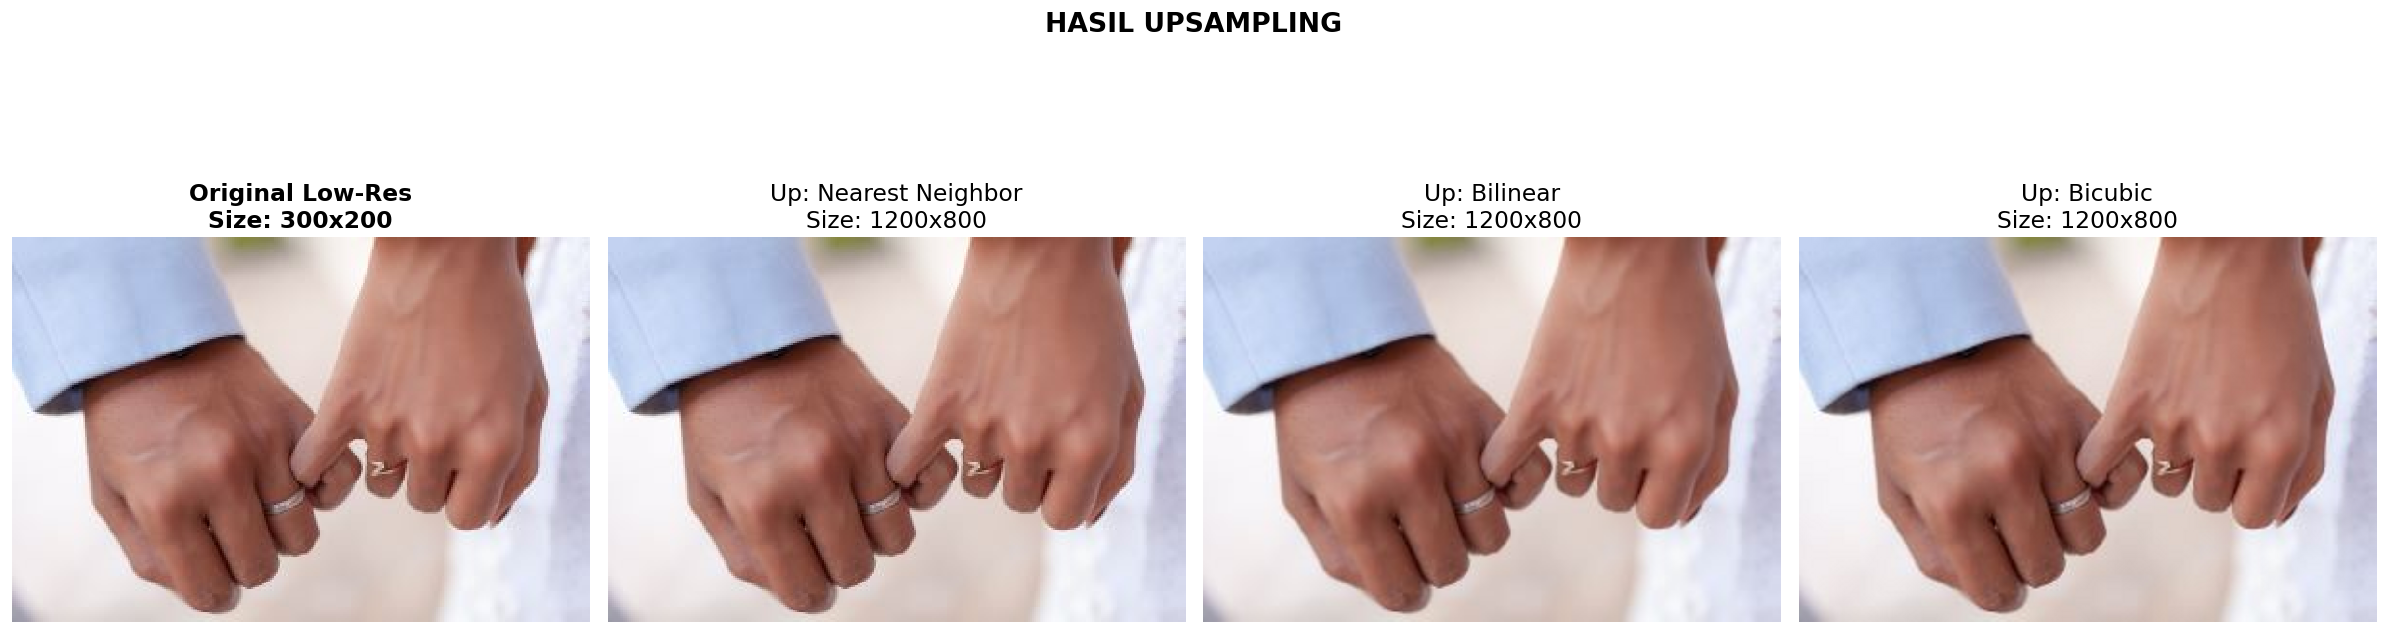

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Tambahan library untuk download file di Google Colab
from google.colab import files

def load_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. DOWN SAMPLING
def down_sample_manual(image, block_size, method='average'):
    h, w, c = image.shape
    h_new = h // block_size
    w_new = w // block_size

    result = np.zeros((h_new, w_new, c), dtype=np.uint8)

    for y in range(h_new):
        for x in range(w_new):
            if method == 'average':
                sum_r, sum_g, sum_b = 0, 0, 0
                for by in range(block_size):
                    for bx in range(block_size):
                        pixel = image[(y * block_size) + by, (x * block_size) + bx]
                        sum_r += int(pixel[0])
                        sum_g += int(pixel[1])
                        sum_b += int(pixel[2])

                total = block_size * block_size
                result[y, x, 0] = sum_r // total
                result[y, x, 1] = sum_g // total
                result[y, x, 2] = sum_b // total

            elif method == 'max':
                max_r, max_g, max_b = 0, 0, 0
                for by in range(block_size):
                    for bx in range(block_size):
                        pixel = image[(y * block_size) + by, (x * block_size) + bx]
                        if pixel[0] > max_r: max_r = pixel[0]
                        if pixel[1] > max_g: max_g = pixel[1]
                        if pixel[2] > max_b: max_b = pixel[2]

                result[y, x, 0] = max_r
                result[y, x, 1] = max_g
                result[y, x, 2] = max_b

            elif method == 'median':
                r_list, g_list, b_list = [], [], []
                for by in range(block_size):
                    for bx in range(block_size):
                        pixel = image[(y * block_size) + by, (x * block_size) + bx]
                        r_list.append(pixel[0])
                        g_list.append(pixel[1])
                        b_list.append(pixel[2])

                r_list.sort()
                g_list.sort()
                b_list.sort()

                mid_index = len(r_list) // 2
                result[y, x, 0] = r_list[mid_index]
                result[y, x, 1] = g_list[mid_index]
                result[y, x, 2] = b_list[mid_index]

    return result

# 2. UP SAMPLING
def up_sample_nn_manual(image, scale_factor):
    h, w, c = image.shape
    h_new, w_new = h * scale_factor, w * scale_factor
    result = np.zeros((h_new, w_new, c), dtype=np.uint8)

    for y in range(h_new):
        for x in range(w_new):
            orig_y = y // scale_factor
            orig_x = x // scale_factor
            result[y, x] = image[orig_y, orig_x]

    return result

def up_sample_bilinear_manual(image, scale_factor):
    h, w, c = image.shape
    h_new, w_new = h * scale_factor, w * scale_factor
    result = np.zeros((h_new, w_new, c), dtype=np.uint8)

    for y in range(h_new):
        for x in range(w_new):
            orig_x = x / scale_factor
            orig_y = y / scale_factor

            x1 = int(orig_x)
            y1 = int(orig_y)
            x2 = min(x1 + 1, w - 1)
            y2 = min(y1 + 1, h - 1)

            dx = orig_x - x1
            dy = orig_y - y1

            for k in range(c):
                p11 = image[y1, x1, k]
                p21 = image[y1, x2, k]
                p12 = image[y2, x1, k]
                p22 = image[y2, x2, k]

                top_row = p11 * (1 - dx) + p21 * dx
                bottom_row = p12 * (1 - dx) + p22 * dx
                final_val = top_row * (1 - dy) + bottom_row * dy

                result[y, x, k] = int(final_val)

    return result

def cubic_weight(x):
    x = abs(x)
    if x <= 1:
        return 1.5 * (x**3) - 2.5 * (x**2) + 1
    elif x < 2:
        return -0.5 * (x**3) + 2.5 * (x**2) - 4 * x + 2
    return 0.0

def up_sample_bicubic_manual(image, scale_factor):
    h, w, c = image.shape
    h_new, w_new = h * scale_factor, w * scale_factor
    result = np.zeros((h_new, w_new, c), dtype=np.uint8)

    for y in range(h_new):
        for x in range(w_new):
            orig_x = x / scale_factor
            orig_y = y / scale_factor

            x_int = int(orig_x)
            y_int = int(orig_y)
            dx = orig_x - x_int
            dy = orig_y - y_int

            pixel_val = [0.0, 0.0, 0.0]

            for m in range(-1, 3):
                for n in range(-1, 3):
                    cur_x = min(max(x_int + n, 0), w - 1)
                    cur_y = min(max(y_int + m, 0), h - 1)

                    weight = cubic_weight(n - dx) * cubic_weight(m - dy)

                    for k in range(c):
                        pixel_val[k] += image[cur_y, cur_x, k] * weight

            for k in range(c):
                result[y, x, k] = min(max(int(pixel_val[k]), 0), 255)

    return result


# EKSEKUSI
img_high_res = load_image('gambar_high_res.jpg')
img_low_res = load_image('gambar_low_res.jpg')

block_size = 4
scale_factor = 4

# 1. Eksekusi Downsampling
print("Memproses Downsampling")
img_down_max = down_sample_manual(img_high_res, block_size, 'max')
img_down_avg = down_sample_manual(img_high_res, block_size, 'average')
img_down_med = down_sample_manual(img_high_res, block_size, 'median')

# 2. Eksekusi Upsampling
print("Memproses Upsampling Nearest Neighbor...")
img_up_nn = up_sample_nn_manual(img_low_res, scale_factor)

print("Memproses Upsampling Bilinear...")
img_up_bilinear = up_sample_bilinear_manual(img_low_res, scale_factor)

print("Memproses Upsampling Bicubic")
img_up_bicubic = up_sample_bicubic_manual(img_low_res, scale_factor)


# VISUALISASI
fig1, axes1 = plt.subplots(1, 4, figsize=(20, 6), dpi=120)
axes1[0].imshow(img_high_res, interpolation='nearest')
axes1[0].set_title(f"Original High-Res\nSize: {img_high_res.shape[1]}x{img_high_res.shape[0]}", fontsize=14, fontweight='bold')
axes1[1].imshow(img_down_max, interpolation='nearest')
axes1[1].set_title(f"Down: Max\nSize: {img_down_max.shape[1]}x{img_down_max.shape[0]}", fontsize=14)
axes1[2].imshow(img_down_avg, interpolation='nearest')
axes1[2].set_title(f"Down: Average\nSize: {img_down_avg.shape[1]}x{img_down_avg.shape[0]}", fontsize=14)
axes1[3].imshow(img_down_med, interpolation='nearest')
axes1[3].set_title(f"Down: Median\nSize: {img_down_med.shape[1]}x{img_down_med.shape[0]}", fontsize=14)

for ax in axes1:
    ax.axis('off')

plt.suptitle("HASIL DOWNSAMPLING", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(1, 4, figsize=(20, 6), dpi=120)
axes2[0].imshow(img_low_res, interpolation='nearest')
axes2[0].set_title(f"Original Low-Res\nSize: {img_low_res.shape[1]}x{img_low_res.shape[0]}", fontsize=14, fontweight='bold')
axes2[1].imshow(img_up_nn, interpolation='nearest')
axes2[1].set_title(f"Up: Nearest Neighbor\nSize: {img_up_nn.shape[1]}x{img_up_nn.shape[0]}", fontsize=14)
axes2[2].imshow(img_up_bilinear, interpolation='nearest')
axes2[2].set_title(f"Up: Bilinear\nSize: {img_up_bilinear.shape[1]}x{img_up_bilinear.shape[0]}", fontsize=14)
axes2[3].imshow(img_up_bicubic, interpolation='nearest')
axes2[3].set_title(f"Up: Bicubic\nSize: {img_up_bicubic.shape[1]}x{img_up_bicubic.shape[0]}", fontsize=14)

for ax in axes2:
    ax.axis('off')

plt.suptitle("HASIL UPSAMPLING", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()